In [40]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [41]:
 train_data_dir = '/kaggle/input/1000-videos-split/1000_videos/train'
valid_data_dir = '/kaggle/input/1000-videos-split/1000_videos/validation'
test_data_dir = '/kaggle/input/1000-videos-split/1000_videos/test'  

In [42]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [43]:
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [44]:
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 11633 images belonging to 2 classes.


In [45]:
valid_generator = valid_datagen.flow_from_directory(
    valid_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 2400 images belonging to 2 classes.


In [46]:
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2400 images belonging to 2 classes.


In [47]:
class_labels = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(class_labels), y=class_labels)
class_weights = {0: class_weights[0], 1: class_weights[1]}  

In [48]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [49]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [50]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)  # Add Dropout
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)  # Add Dropout
predictions = Dense(1, activation='sigmoid')(x)

In [51]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [52]:
history = model.fit(
    train_generator,
    epochs=10,  # Adjust as necessary
    validation_data=valid_generator,
    class_weight=class_weights  # Use class weights
)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


364/364 ━━━━━━━━━━━━━━━━━━━━ 226s 507ms/step - accuracy: 0.9683 - loss: 0.0792 - val_accuracy: 0.8792 - val_loss: 0.5705
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 227s 452ms/step - accuracy: 0.9693 - loss: 0.0686 - val_accuracy: 0.7983 - val_loss: 1.0509
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 170s 457ms/step - accuracy: 0.9731 - loss: 0.0634 - val_accuracy: 0.8712 - val_loss: 0.5002
Epoch 4/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 168s 454ms/step - accuracy: 0.9749 - loss: 0.0594 - val_accuracy: 0.8938 - val_loss: 0.4694
Epoch 5/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 168s 452ms/step - accuracy: 0.9786 - loss: 0.0511 - val_accuracy: 0.9162 - val_loss: 0.3847
Epoch 6/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 169s 455ms/step - accuracy: 0.9772 - loss: 0.0498 - val_accuracy: 0.9100 - val_loss: 0.3585
Epoch 7/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 169s 454ms/step - accuracy: 0.9797 - loss: 0.0460 - val_accuracy: 0.9038 - val_loss: 0.4166
Epoch 8/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 170s 458ms/step - accuracy: 0.9799 - loss: 0.04

In [53]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.8801 - loss: 0.4675
Test Accuracy: 86.79%


In [54]:
test_generator.reset()
Y_pred = model.predict(test_generator)
Y_pred = (Y_pred > 0.5).astype(int)
Y_true = test_generator.classes

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step


In [55]:
conf_matrix = confusion_matrix(Y_true, Y_pred)

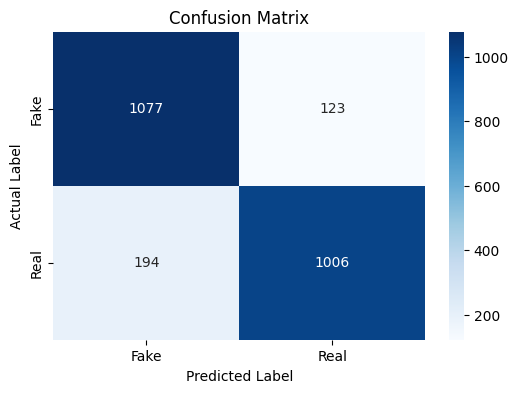

In [56]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [57]:
print(classification_report(Y_true, Y_pred, target_names=['Fake', 'Real']))

              precision    recall  f1-score   support

        Fake       0.85      0.90      0.87      1200
        Real       0.89      0.84      0.86      1200

    accuracy                           0.87      2400
   macro avg       0.87      0.87      0.87      2400
weighted avg       0.87      0.87      0.87      2400



In [58]:
model.save('deepfake_detector_model_improved_with_weights.h5')